# Global Demand Forecasting using Seasonal ARIMA

This notebook trains a Seasonal AutoRegressive Integrated Moving Average (SARIMA) model on the aggregated global daily supply chain demand data to predict product orders up to 90 days in advance, using actual **DataCo Supply Chain** dataset.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Step 1: Load Global Daily Demand Dataset (DataCo raw CSV or processed fallback)

In [2]:
dataco_path = "DataCoSupplyChainDataset.csv"
demand_path = "processed_data/global_daily_demand.csv"

if os.path.exists(dataco_path):
    print(f"Loading actual DataCo dataset from {dataco_path}...")
    df_raw = pd.read_csv(dataco_path, encoding='latin-1')
    
    # Parse dates and group by date to get daily demand
    df_raw['ds'] = pd.to_datetime(df_raw['order date (DateOrders)'])
    # Filter data up to 2026-10-01 to establish evaluation history
    df_raw = df_raw[df_raw['ds'] < '2026-10-01']
    
    df_daily = df_raw.groupby(df_raw['ds'].dt.date).agg(
        y=('Order Item Quantity', 'sum')
    ).reset_index()
    df_daily.rename(columns={'order_date_parsed': 'ds'}, inplace=True)
    df_daily['ds'] = pd.to_datetime(df_daily['ds'])
    df_ts = df_daily.set_index('ds')[['y']]
elif os.path.exists(demand_path):
    print(f"Loading preprocessed features from {demand_path}...")
    df = pd.read_csv(demand_path)
    df['ds'] = pd.to_datetime(df['ds'])
    df_ts = df.set_index('ds')[['y']]
else:
    print("Warning: No dataset found. Generating mock timeseries data...")
    np.random.seed(42)
    dates = pd.date_range(start="2026-01-01", end="2026-09-30", freq='D')
    y = 100 + np.sin(dates.dayofweek * (2 * np.pi / 7)) * 25 + np.random.normal(0, 10, len(dates))
    df_ts = pd.DataFrame({'y': y}, index=dates)
    df_ts.index.name = 'ds'

df_ts = df_ts.asfreq('D', fill_value=0.0)
print(f"Total historical data points: {len(df_ts)}")
df_ts.head(10)

Loading actual DataCo dataset from DataCoSupplyChainDataset.csv...
Total historical data points: 1004


,y
ds,
2024-01-01,355.0
2024-01-02,354.0
2024-01-03,392.0
2024-01-04,410.0
2024-01-05,373.0
2024-01-06,368.0
2024-01-07,350.0
2024-01-08,387.0
2024-01-09,308.0


### Step 2: Tune SARIMA Hyperparameters
We search a small grid of non-seasonal and seasonal orders using a 30-day validation split, then choose the lowest validation RMSE.

In [3]:
train = df_ts.iloc[:-30]
test = df_ts.iloc[-30:]
print(f"Training days: {len(train)}, validation days: {len(test)}")

best_rmse = np.inf
best_order = None
best_seasonal = None

for p in [0, 1, 2]:
    for d in [0, 1]:
        for q in [0, 1, 2]:
            for P in [0, 1]:
                for D in [0, 1]:
                    for Q in [0, 1]:
                        order = (p, d, q)
                        # p is the order of the autoregressive part, d is the degree of differencing, q is the order of the moving average part
                        """ p This uses past values of the series to predict the current one.
This uses past values of the series to predict the current one.Higher p means the model looks further back into the history
large p can capture strong repeating patterns and can overfit hehe. d = differencing order
This is about making the series more stationary.
Stationary means the mean and variance do not change too much over time.
If the series has a trend, differencing helps remove it. q = moving average order
This uses past forecast errors to predict the current value.
It helps the model correct itself when previous predictions were off.
"""
                        seasonal_order = (P, D, Q, 7)
                        try:
                            candidate = ARIMA(train['y'], order=order, seasonal_order=seasonal_order)
                            result = candidate.fit()
                            pred_val = result.forecast(steps=len(test))
                            val_rmse = np.sqrt(mean_squared_error(test['y'], pred_val))
                            if val_rmse < best_rmse:
                                best_rmse = val_rmse
                                best_order = order
                                best_seasonal = seasonal_order
                        except Exception:
                            continue

print('Best SARIMA configuration found:')
print(f'  order={best_order}, seasonal_order={best_seasonal}, validation RMSE={best_rmse:.2f}')

Training days: 974, validation days: 30


C:\Users\Sabor\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Sabor\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Sabor\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Sabor\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('

Best SARIMA configuration found:
  order=(2, 1, 1), seasonal_order=(1, 0, 1, 7), validation RMSE=31.34


### Step 3: Fit Selected SARIMA Model
We fit the selected seasonal ARIMA model on the full historical dataset.

In [ ]:
model = ARIMA(df_ts['y'], order=best_order, seasonal_order=best_seasonal)
model_fit = model.fit()

# Simple evaluation on the last validation window
pred_val = model_fit.forecast(steps=len(test))
val_mae = mean_absolute_error(test['y'], pred_val)
val_rmse = np.sqrt(mean_squared_error(test['y'], pred_val))

print('Simple SARIMA evaluation:')
print(f'  MAE:  {val_mae:.2f}')
print(f'  RMSE: {val_rmse:.2f}')


Simple SARIMA evaluation:
  MAE:  27.50
  RMSE: 31.83


## in general a 30 demand difference

### Step 4: Residuals Diagnostic Plot

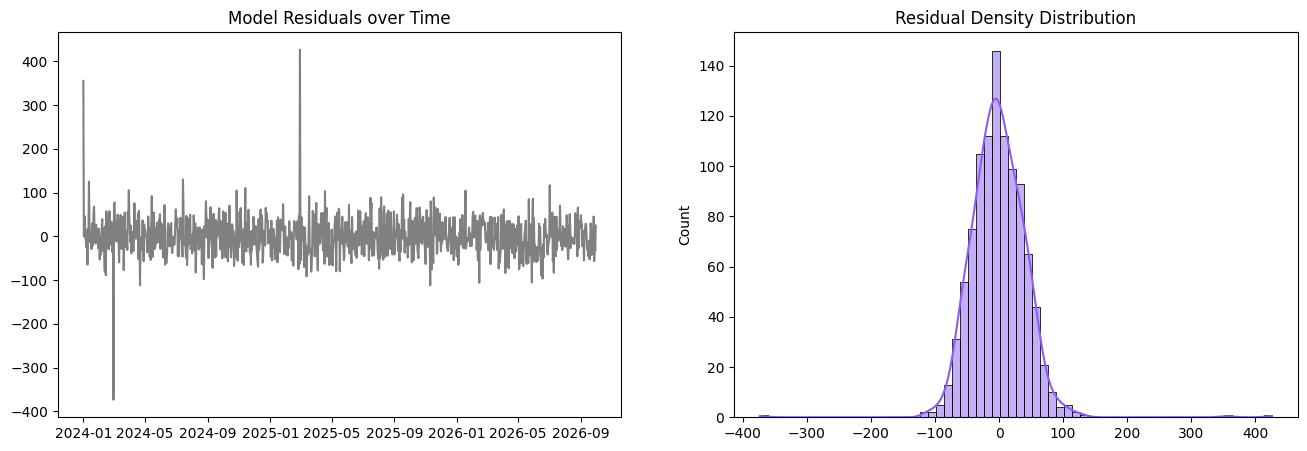

In [ ]:
residuals = model_fit.resid
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(residuals, color='gray')
ax[0].set_title('Model Residuals over Time')

sns.histplot(residuals, kde=True, color='#8b5cf6', ax=ax[1])
ax[1].set_title('Residual Density Distribution')
plt.show()

### Step 5: Forecast Future Demand & Plot Results
We generate historical in-sample predictions and predict future demand out to 90 steps (days).